# SURROGATE MODELLING FOR BINARY DISTILLATION

### Binary Distillation
Binary distillation is a separation process used to separate a mixture of two components into two product streams (distillate and bottoms) based on their relative volatility. The lighter component concentrates in the distillate, while the heavier component concentrates in the bottoms. In this specific project, the lighter key is **Benzene**, and the heavier key is **Toluene**.

### Surrogate Modelling
Surrogate modeling is a method of using machine learning algorithms to approximate the results of complex physical simulations (like DWSIM). In distillation design, it replaces time-consuming, highly iterative rigorous MESH equation solvers with a fast predictive model, making tasks like dynamic optimization, sensitivity analysis, and energy minimization exponentially faster while retaining thermodynamic accuracy.

---

## Exploratory Data Analysis

### 1) Problem Statement
This project aims to understand how key distillation performance metricsâ€”specifically distillate purity ($x_D$), bottoms purity ($x_B$), condenser duty ($Q_C$), and reboiler duty ($Q_R$)â€”are affected by varying operating conditions. The objective is to evaluate multiple machine learning frameworks to predict these non-linear thermodynamic targets based on independent variables including feed temperature, feed pressure, feed composition, number of stages, feed stage location, reflux ratio, and bottoms withdrawal rate.

### 2) Data Collection
Data was generated headlessly using the DWSIM open-source process simulator via an automated IronPython script. The parameter space was explored utilizing Latin Hypercube Sampling (LHS) to ensure statistical diversity. 

**Simulation Specifications:**
* **Chemical System:** Benzene - Toluene
* **Thermodynamic Model:** Peng-Robinson (PR)
* **Dataset Size:** 1,000 rows (representing 1,000 converged steady-state simulations)

### 2.1 Import Data and Required Packages

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path=r"D:\FOSSE\DWSIM\data\Dataset.csv"

In [ ]:
df=pd.read_csv(path)

In [4]:
df.columns

Index(['run_index', 'status', 'error_message', 'Feed_Temp_K',
       'Feed_Pressure_Pa', 'Feed_Benzene_Frac', 'Num_Stages', 'Feed_Stage',
       'Reflux_Ratio', 'Bottoms_Rate_mols', 'Column_Pressure_Pa',
       'feed_vapor_fraction', 'distillate_benzene_purity_mole_fraction',
       'bottoms_toluene_purity_mole_fraction', 'condenser_duty_kW',
       'reboiler_duty_kW', 'distillate_molar_flow_mol_s',
       'distillate_volumetric_flow_m3_s',
       'distillate_component_2_mole_fraction', 'distillate_mass_flow_kg_s',
       'distillate_temperature_K', 'distillate_mass_enthalpy',
       'distillate_pressure_Pa', 'distillate_component_1_mole_fraction',
       'bottoms_mass_enthalpy', 'bottoms_pressure_Pa',
       'bottoms_volumetric_flow_m3_s', 'bottoms_component_1_mole_fraction',
       'bottoms_molar_flow_mol_s', 'bottoms_mass_flow_kg_s',
       'bottoms_component_2_mole_fraction', 'bottoms_temperature_K'],
      dtype='str')

In [9]:
df.columns

Index(['Feed_Temp_K', 'Feed_Pressure_Pa', 'Feed_Benzene_Frac', 'Num_Stages',
       'Feed_Stage', 'Reflux_Ratio', 'Bottoms_Rate_mols', 'Column_Pressure_Pa',
       'feed_vapor_fraction', 'distillate_benzene_purity_mole_fraction',
       'bottoms_toluene_purity_mole_fraction', 'condenser_duty_kW',
       'reboiler_duty_kW', 'distillate_molar_flow_mol_s',
       'distillate_volumetric_flow_m3_s',
       'distillate_component_2_mole_fraction', 'distillate_mass_flow_kg_s',
       'distillate_temperature_K', 'distillate_mass_enthalpy',
       'distillate_pressure_Pa', 'distillate_component_1_mole_fraction',
       'bottoms_mass_enthalpy', 'bottoms_pressure_Pa',
       'bottoms_volumetric_flow_m3_s', 'bottoms_component_1_mole_fraction',
       'bottoms_molar_flow_mol_s', 'bottoms_mass_flow_kg_s',
       'bottoms_component_2_mole_fraction', 'bottoms_temperature_K'],
      dtype='str')

In [ ]:
columns_to_drop=["run_index","status","error_message"]

In [ ]:
df.drop(columns=columns_to_drop,inplace=True)

In [25]:
# renaming columns for better readability
rename_map = {
    # Inputs
    'Feed_Temp_K': 'feed_temp_k',
    'Feed_Pressure_Pa': 'feed_pressure_pa',
    'Feed_Benzene_Frac': 'feed_benzene_frac',
    'Num_Stages': 'num_stages',
    'Feed_Stage': 'feed_stage',
    'Reflux_Ratio': 'reflux_ratio',
    'Bottoms_Rate_mols': 'bot_rate_mol_s',
    'Column_Pressure_Pa': 'col_pressure_pa',
    
    
    'condenser_duty_kW': 'condenser_duty_kw',
    'reboiler_duty_kW': 'reboiler_duty_kw',
    'distillate_benzene_purity_mole_fraction': 'dist_benzene_frac',
    'bottoms_toluene_purity_mole_fraction': 'bot_toluene_frac',
    
    # Distillate Physical Properties
    'distillate_temperature_K': 'dist_temp_k',
    'distillate_pressure_Pa': 'dist_pressure_pa',
    'distillate_molar_flow_mol_s': 'dist_molar_flow_mol_s',
    'distillate_mass_flow_kg_s': 'dist_mass_flow_kg_s',
    'distillate_volumetric_flow_m3_s': 'dist_vol_flow_m3_s',
    'distillate_mass_enthalpy': 'dist_mass_enthalpy_kj_kg',
    
    # Bottoms Physical Properties
    'bottoms_temperature_K': 'bot_temp_k',
    'bottoms_pressure_Pa': 'bot_pressure_pa',
    'bottoms_molar_flow_mol_s': 'bot_molar_flow_mol_s',
    'bottoms_mass_flow_kg_s': 'bot_mass_flow_kg_s',
    'bottoms_volumetric_flow_m3_s': 'bot_vol_flow_m3_s',
    'bottoms_mass_enthalpy': 'bot_mass_enthalpy_kj_kg'
}

In [ ]:
df.rename(columns=rename_map,inplace=True)

In [ ]:
df

 ## 3 Data Checks to perform
* Check Missing values
* Check Duplicates
* Check data type
* Check the number of unique values of each column
* Check statistics of data set
* Check various categories present in the different categorical column
* Check for unit consistency

### 3.1 Check Missing Values

In [13]:
df.isna().sum()

feed_temp_k                             0
feed_pressure_pa                        0
feed_benzene_frac                       0
num_stages                              0
feed_stage                              0
reflux_ratio                            0
bot_rate_mol_s                          0
col_pressure_pa                         0
feed_vapor_fraction                     1
dist_benzene_frac                       1
bot_toluene_frac                        1
condenser_duty_kw                       1
reboiler_duty_kw                        1
dist_molar_flow_mol_s                   1
dist_vol_flow_m3_s                      1
distillate_component_2_mole_fraction    1
dist_mass_flow_kg_s                     1
dist_temp_k                             1
dist_mass_enthalpy_kj_kg                1
dist_pressure_pa                        1
distillate_component_1_mole_fraction    1
bot_mass_enthalpy_kj_kg                 1
bot_pressure_pa                         1
bot_vol_flow_m3_s                 

there is 1 missing value in the dataset.

In [15]:
df.dropna(inplace=True)

the missing value is dropped from the dataset.

In [19]:
df.shape

(999, 29)

In [20]:
df.isna().sum()

feed_temp_k                             0
feed_pressure_pa                        0
feed_benzene_frac                       0
num_stages                              0
feed_stage                              0
reflux_ratio                            0
bot_rate_mol_s                          0
col_pressure_pa                         0
feed_vapor_fraction                     0
dist_benzene_frac                       0
bot_toluene_frac                        0
condenser_duty_kw                       0
reboiler_duty_kw                        0
dist_molar_flow_mol_s                   0
dist_vol_flow_m3_s                      0
distillate_component_2_mole_fraction    0
dist_mass_flow_kg_s                     0
dist_temp_k                             0
dist_mass_enthalpy_kj_kg                0
dist_pressure_pa                        0
distillate_component_1_mole_fraction    0
bot_mass_enthalpy_kj_kg                 0
bot_pressure_pa                         0
bot_vol_flow_m3_s                 

### 3.2 Check Duplicates

In [17]:
df.duplicated().sum()

np.int64(0)

there is no duplicate value in the dataset.

### 3.3 Check Data Types

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   feed_temp_k                           999 non-null    float64
 1   feed_pressure_pa                      999 non-null    float64
 2   feed_benzene_frac                     999 non-null    float64
 3   num_stages                            999 non-null    int64  
 4   feed_stage                            999 non-null    int64  
 5   reflux_ratio                          999 non-null    float64
 6   bot_rate_mol_s                        999 non-null    float64
 7   col_pressure_pa                       999 non-null    float64
 8   feed_vapor_fraction                   999 non-null    float64
 9   dist_benzene_frac                     999 non-null    float64
 10  bot_toluene_frac                      999 non-null    float64
 11  condenser_duty_kw                  

### 3.4 Check the number of unique values of each column

In [22]:
df.nunique()

feed_temp_k                             999
feed_pressure_pa                        999
feed_benzene_frac                       999
num_stages                               11
feed_stage                                8
reflux_ratio                            999
bot_rate_mol_s                          999
col_pressure_pa                         999
feed_vapor_fraction                       1
dist_benzene_frac                       999
bot_toluene_frac                        999
condenser_duty_kw                       999
reboiler_duty_kw                        999
dist_molar_flow_mol_s                   999
dist_vol_flow_m3_s                      999
distillate_component_2_mole_fraction    999
dist_mass_flow_kg_s                     999
dist_temp_k                             999
dist_mass_enthalpy_kj_kg                999
dist_pressure_pa                        999
distillate_component_1_mole_fraction    999
bot_mass_enthalpy_kj_kg                 999
bot_pressure_pa                 

### 3.5 check statistics of data set

In [23]:
df.describe()

,feed_temp_k,feed_pressure_pa,feed_benzene_frac,num_stages,feed_stage,reflux_ratio,bot_rate_mol_s,col_pressure_pa,feed_vapor_fraction,dist_benzene_frac,...,dist_pressure_pa,distillate_component_1_mole_fraction,bot_mass_enthalpy_kj_kg,bot_pressure_pa,bot_vol_flow_m3_s,bottoms_component_1_mole_fraction,bot_molar_flow_mol_s,bot_mass_flow_kg_s,bottoms_component_2_mole_fraction,bot_temp_k
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.0,999.000000,...,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,340.010279,126923.572592,0.499923,19.994995,10.501502,2.349512,50.007824,110656.535877,0.0,0.886847,...,3154.971885,57812.565837,659.273302,59833.858388,3.073054,50038.785673,1.750719,27.953422,370.060823,-98.000151
std,11.553945,12602.909387,0.115556,2.914097,2.064042,0.664397,5.773821,5393.723390,0.0,0.136330,...,17480.015507,55421.526441,9339.829606,55328.687455,4.247772,55202.036414,8.044099,23.162194,67.275770,174.790260
min,320.018249,101469.681808,0.300000,15.000000,7.000000,1.201528,40.003619,101332.907303,0.0,0.483425,...,352.854815,0.483425,-291.742283,-282.576790,0.004833,0.000147,0.000015,0.004867,0.520886,-292.153660
25%,330.036165,116660.165188,0.399955,17.500000,9.000000,1.774471,45.023777,105998.672549,0.0,0.784280,...,355.599125,0.977922,-252.317454,0.063305,0.948788,0.005723,0.005872,4.545186,378.046409,-253.244853
50%,340.033678,125649.817200,0.499761,20.000000,11.000000,2.348588,50.001216,110662.311509,0.0,0.966042,...,357.626352,102119.213956,0.000157,102908.813786,3.750028,0.006809,0.654353,40.759749,383.839955,-242.208031
75%,349.996648,137834.152467,0.599967,22.000000,12.000000,2.925412,55.000066,115305.559680,0.0,0.998593,...,361.188830,110960.152313,0.060847,111203.383929,4.583322,109532.778238,0.973822,50.244247,386.414524,50.366630
max,359.993728,149978.764951,0.699617,25.000000,14.000000,3.499296,59.995504,119982.792454,0.0,0.999986,...,119086.400571,119982.792454,118339.706811,119982.792454,56.390752,119972.825372,59.114995,59.995504,389.872561,388.992510


### 3.6 Exploring data

In [24]:
df.head()

,feed_temp_k,feed_pressure_pa,feed_benzene_frac,num_stages,feed_stage,reflux_ratio,bot_rate_mol_s,col_pressure_pa,feed_vapor_fraction,dist_benzene_frac,...,dist_pressure_pa,distillate_component_1_mole_fraction,bot_mass_enthalpy_kj_kg,bot_pressure_pa,bot_vol_flow_m3_s,bottoms_component_1_mole_fraction,bot_molar_flow_mol_s,bot_mass_flow_kg_s,bottoms_component_2_mole_fraction,bot_temp_k
0,326.328623,130658.731992,0.689545,24,7,1.775115,59.114995,109658.775745,0.0,0.993803,...,109658.775745,0.993803,-289.208647,109658.775745,0.006337,0.479114,59.114995,5.049490,0.520886,368.530761
1,357.706318,134783.687272,0.645057,15,12,3.182760,52.840368,117801.108336,0.0,0.999742,...,117801.108336,0.999742,-272.818638,117801.108336,0.005866,0.328503,52.840368,4.625152,0.671497,375.974594
2,348.551683,115671.563042,0.562762,25,9,1.884727,56.551680,110832.717041,0.0,0.994955,...,110832.717041,0.994955,-268.790596,110832.717041,0.006389,0.230710,56.551680,5.027578,0.769290,377.317945
3,356.654294,118826.502849,0.544219,21,14,2.460919,49.694244,118826.502849,0.0,0.999766,...,118826.502849,0.999766,-250.252436,118826.502849,0.005814,0.083066,49.694244,4.520849,0.916934,385.812900
4,356.405741,130611.584642,0.479394,25,12,2.213190,54.419260,117769.995488,0.0,0.998750,...,117769.995488,0.998750,-247.011403,117769.995488,0.006417,0.044390,54.419260,4.980221,0.955610,387.193894


## 4 Exploring Data ( Visualization )

### 4.1 UNIVARIATE ANALYSIS

We first examine the core independent operating conditions (inputs) and the primary distillation performance metrics (targets). Since the input data was generated using Latin Hypercube Sampling (LHS), we expect to see a uniform spread across the parameter space, while the targets will reveal the non-linear thermodynamic responses of the column.

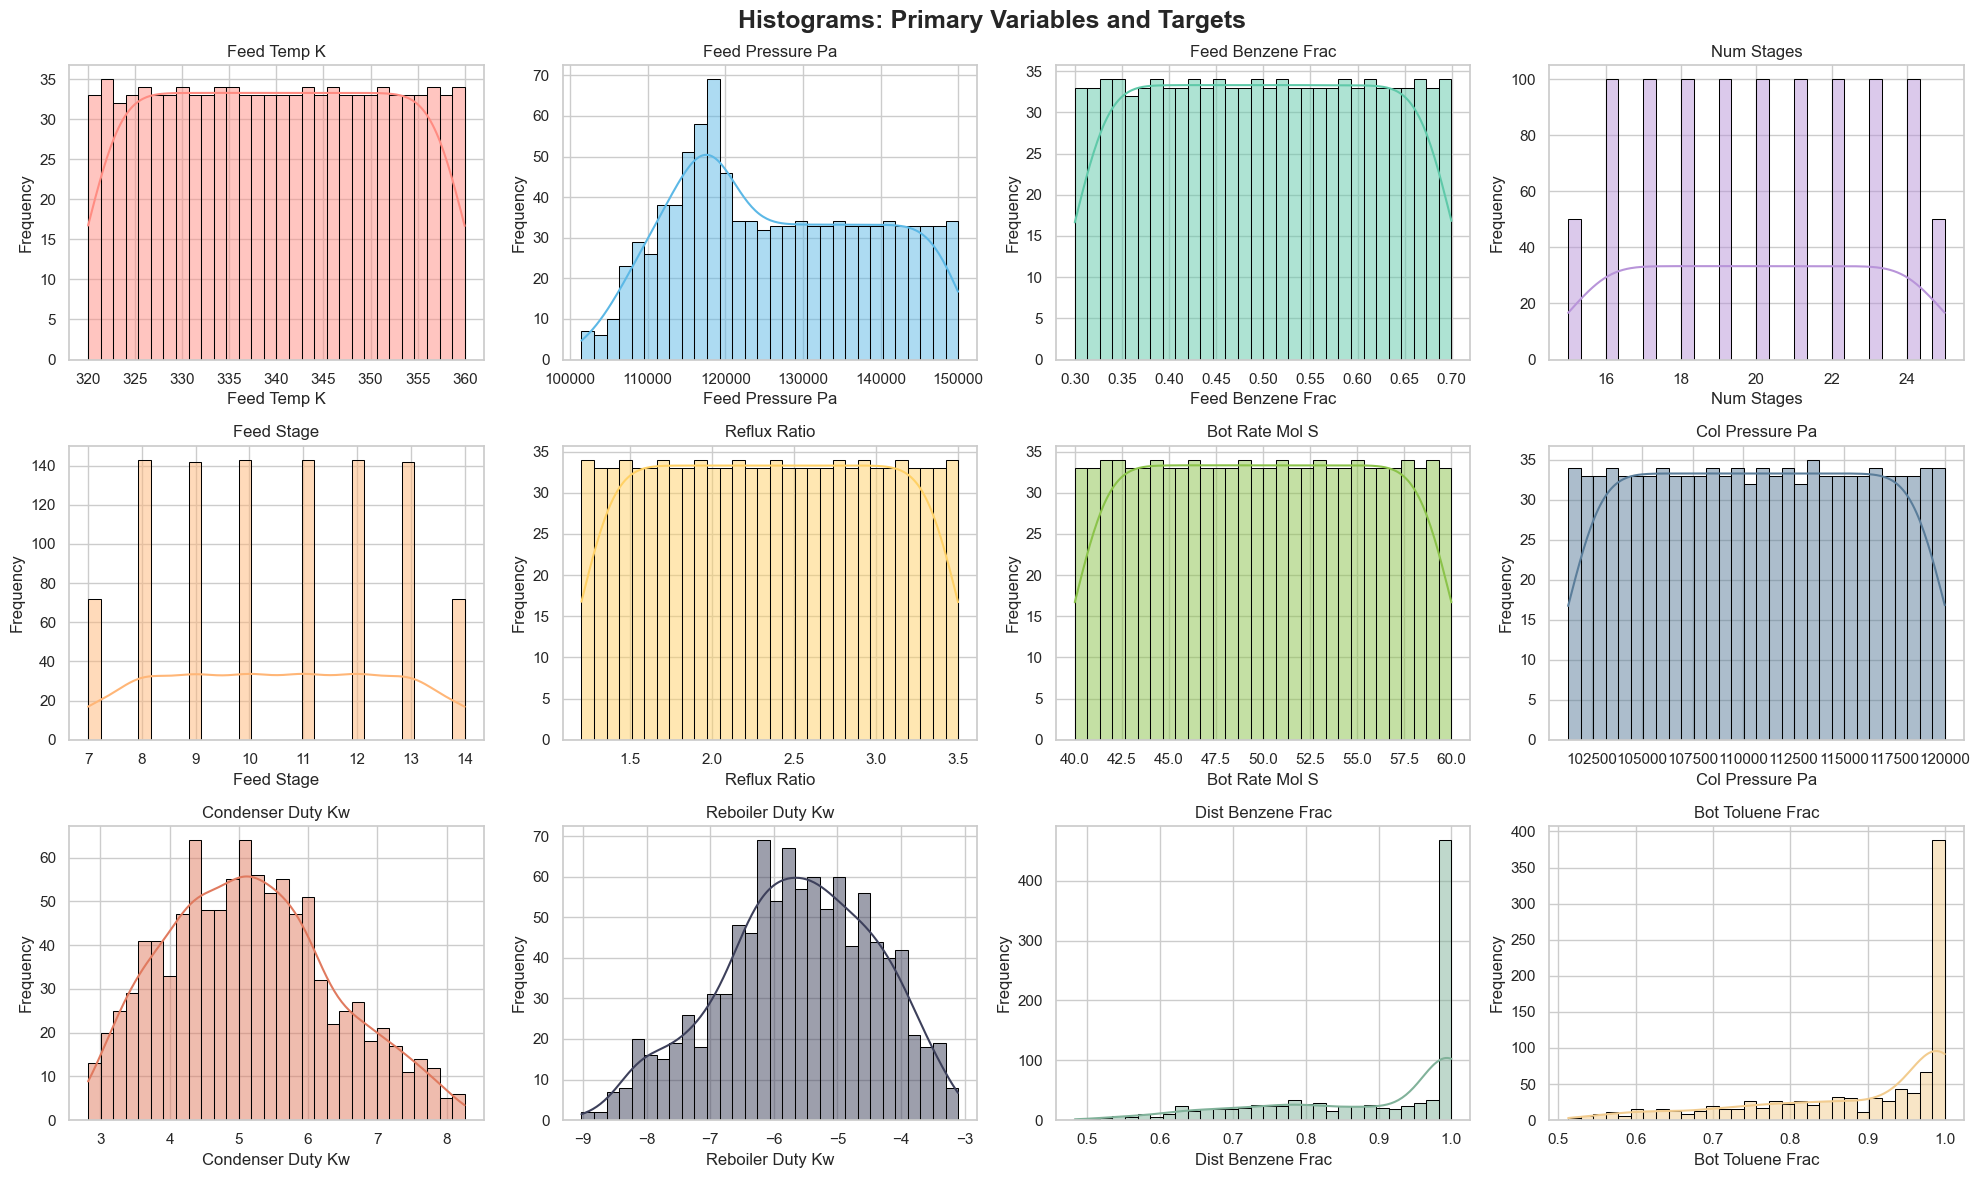

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

# Define the primary inputs and targets
primary_cols = [
    'feed_temp_k', 'feed_pressure_pa', 'feed_benzene_frac', 'num_stages', 
    'feed_stage', 'reflux_ratio', 'bot_rate_mol_s', 'col_pressure_pa',
    'condenser_duty_kw', 'reboiler_duty_kw', 'dist_benzene_frac', 'bot_toluene_frac'
]

n_rows = math.ceil(len(primary_cols) / 4)
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 4 * n_rows))
fig.suptitle("HISTOGRAMS - Primary Operating Variables & Targets", fontsize=20, fontweight="bold", y=1.02)
axes = axes.flatten()

# Custom colors for a beautiful, scientific look
colors = ['#FF8C82', '#5CB8E6', '#5FC9A9', '#B894D9', '#FFB677', '#FFD166', 
          '#8BC34A', '#5A7D9A', '#E07A5F', '#3D405B', '#81B29A', '#F2CC8F']

for ax, col, color in zip(axes, primary_cols, colors):
    sns.histplot(df[col], bins=30, color=color, kde=True, ax=ax, edgecolor='black')
    
    clean_title = col.replace('_', ' ').title()
    ax.set_xlabel(clean_title, fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.set_title(f"{clean_title}", fontsize=13)

# Hide any empty subplots
for j in range(len(primary_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**PRIMARY INSIGHTS:**
* **Uniform Operating Space:** The input variables sampled via LHS (`feed_temp_k`, `feed_pressure_pa`, `reflux_ratio`, etc.) show exceptionally flat, uniform distributions. This confirms the parameter space was explored thoroughly without sampling bias.
* **Discrete Variables:** `num_stages` and `feed_stage` show distinct categorical steps. However, as they represent the physical height and geometry of the column, they will be treated as continuous features during modeling.
* **Purity Targets:** Both `dist_benzene_frac` and `bot_toluene_frac` show high-frequency clustering near 1.0, indicating that a significant portion of the LHS iterations successfully achieved high separation purity, with a longer tail representing sub-optimal configurations.
* **Energy Duties:** `condenser_duty_kw` and `reboiler_duty_kw` exhibit roughly bell-shaped (normal) distributions, reflecting the natural thermodynamic variations required to drive the separation across the sampled geometries.


Next, we analyze the resulting physical and thermodynamic properties of the distillate and bottoms streams. These secondary variables (mass flows, enthalpies, temperatures) are tightly coupled to the primary targets through the rigorous MESH equations solved by DWSIM.

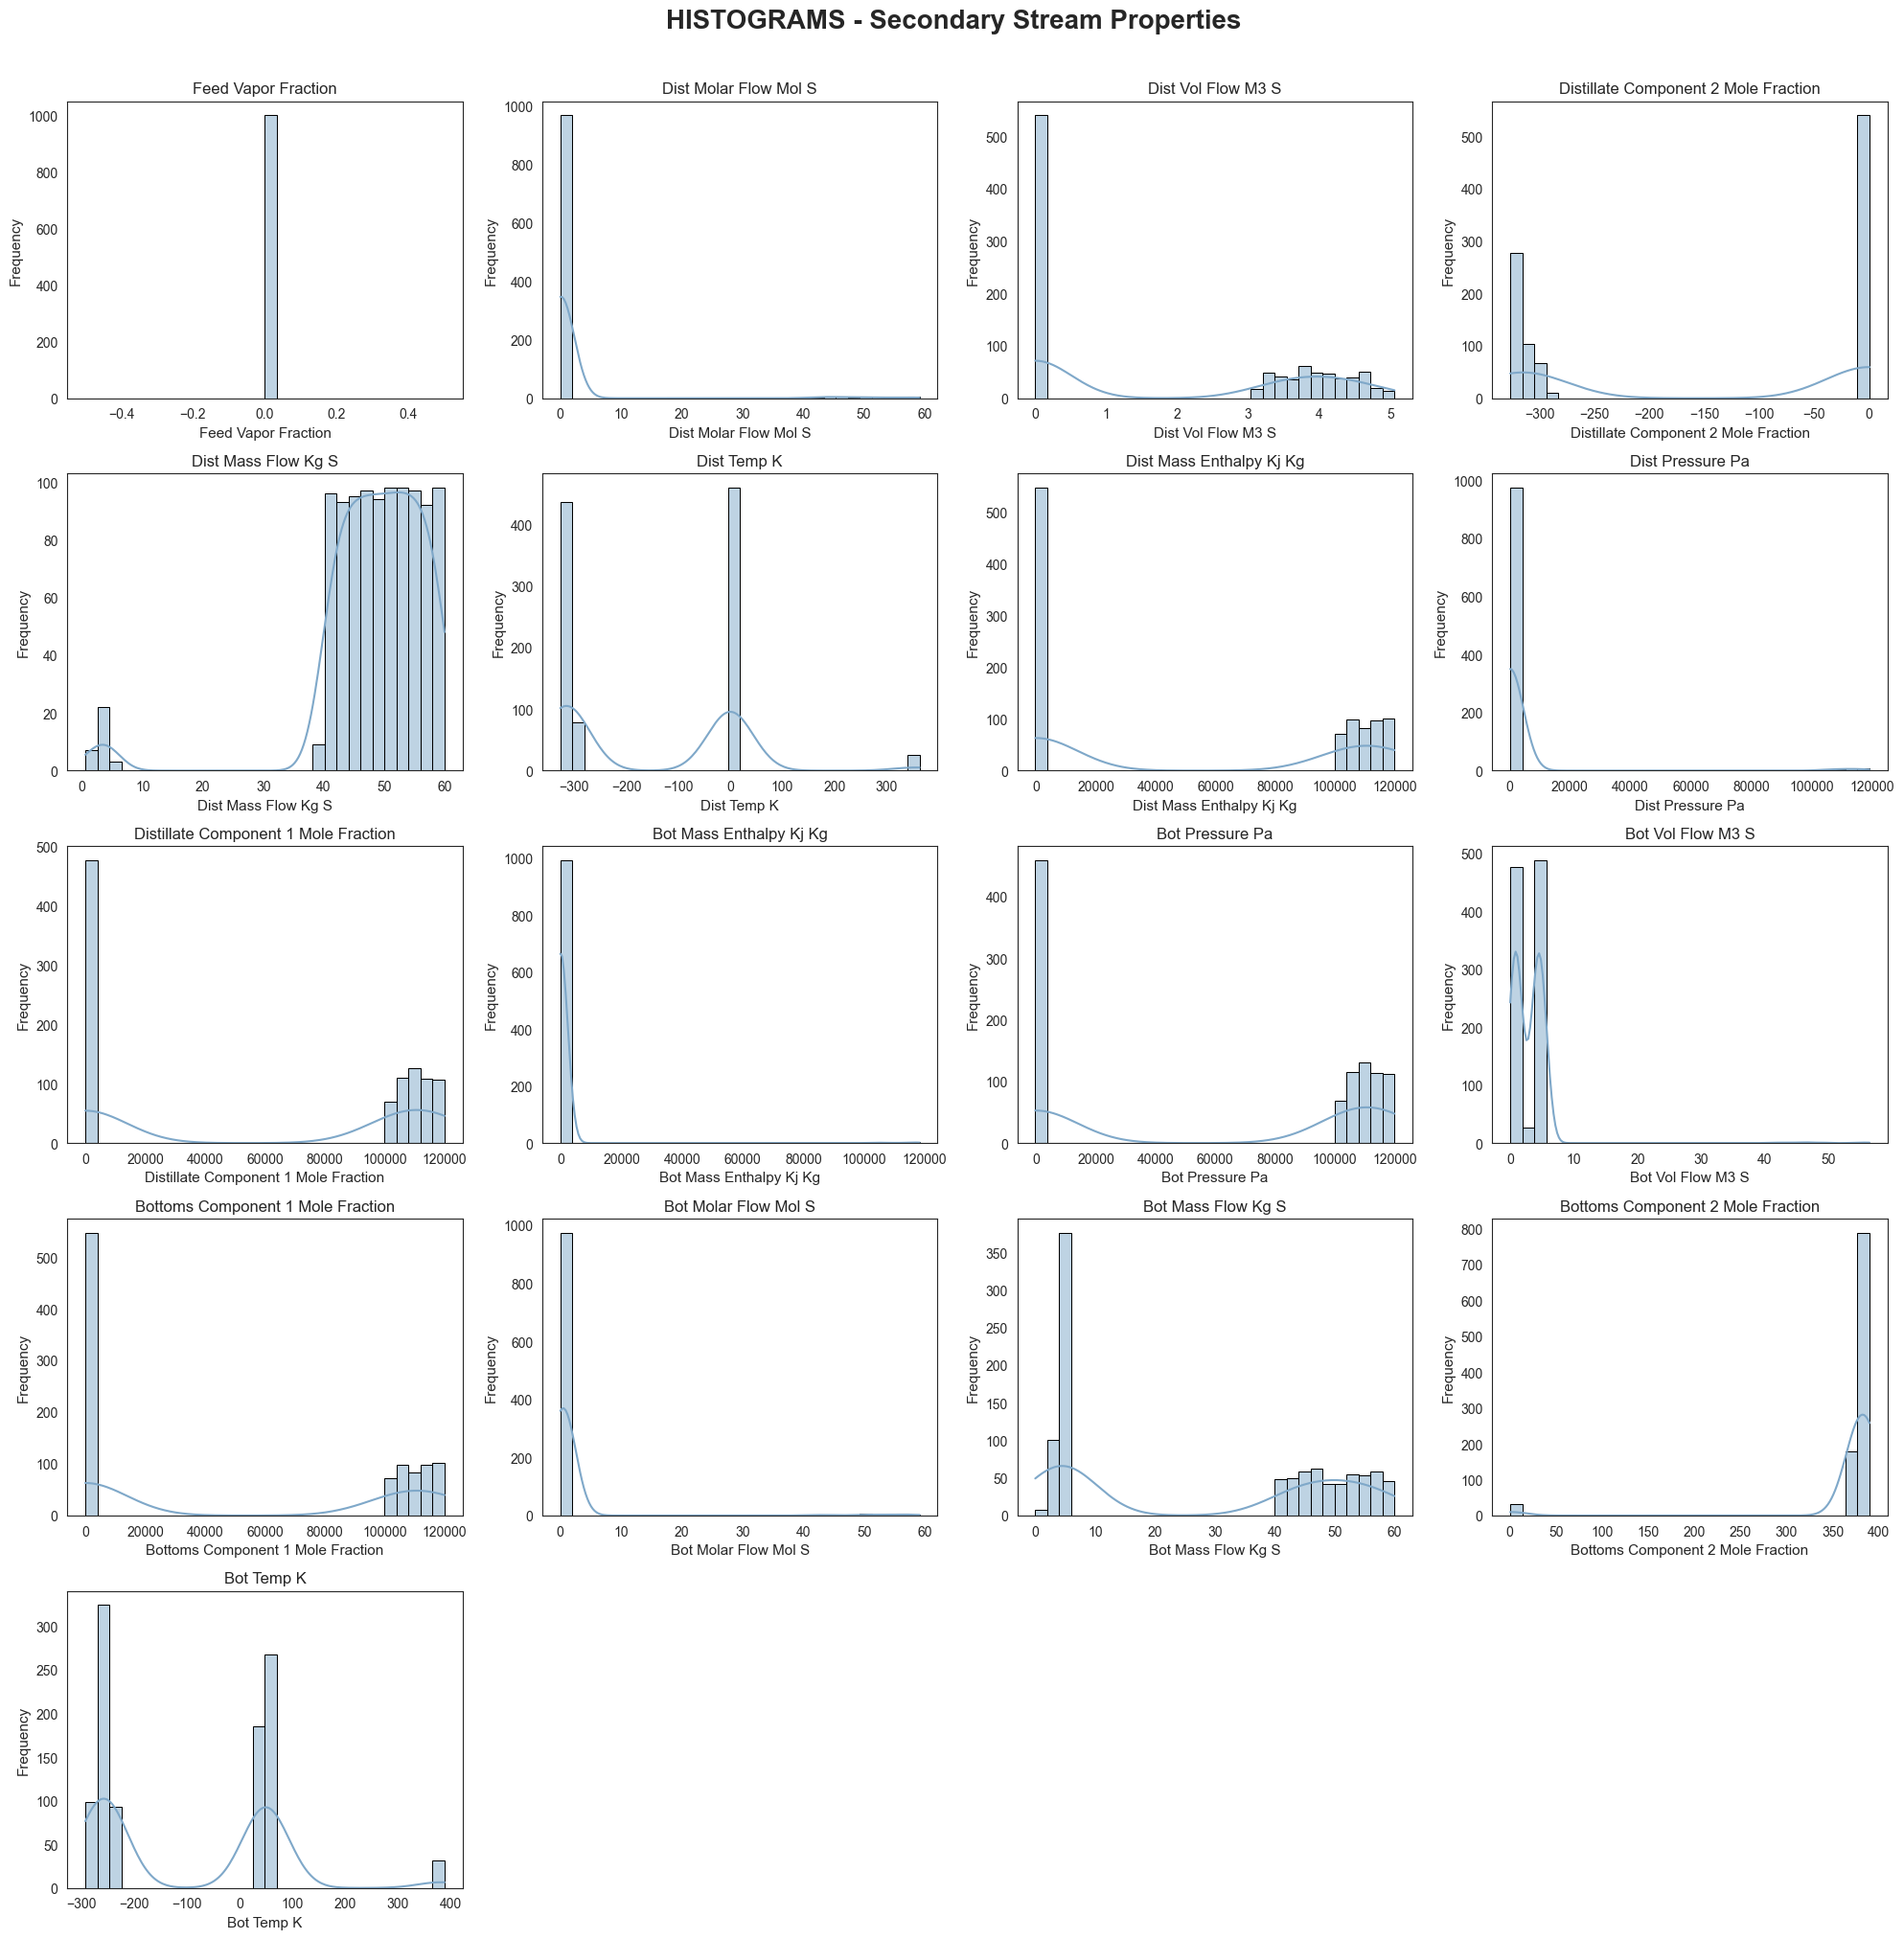

In [ ]:
secondary_cols = [col for col in df.columns if col not in primary_cols]

n_rows = math.ceil(len(secondary_cols) / 4)
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 4 * n_rows))
fig.suptitle("HISTOGRAMS - Secondary Stream Properties", fontsize=20, fontweight="bold", y=1.01)
axes = axes.flatten()

base_color = '#7FA8C9' # A clean, uniform blue for secondary properties

for i, col in enumerate(secondary_cols):
    sns.histplot(df[col], bins=30, color=base_color, kde=True, ax=axes[i], edgecolor='black')
    
    clean_title = col.replace('_', ' ').title()
    axes[i].set_xlabel(clean_title, fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)
    axes[i].set_title(f"{clean_title}", fontsize=12)

for j in range(len(secondary_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**SECONDARY INSIGHTS:**
* **Thermodynamic Coupling:** The distributions for stream temperatures and enthalpies strongly mirror the pressure and composition profiles of the column.
* **Flow Rates:** Volumetric and mass flow distributions are highly dependent on the specified `bot_rate_mol_s` and the overall mass balance of the column.
* **Phase Changes:** The tight distributions in enthalpies reflect the latent heat of vaporization differences between the Benzene and Toluene phases across the condenser and reboiler.

### 4.12 BOX PLOTS

Boxplots: Outlier Detection for Primary Variables
Boxplots are highly effective for visualizing the median, quartiles, and extreme outliers in the dataset. 
* For our **independent inputs** (sampled via LHS), we expect to see wide, boxy distributions with no outliers, representing our defined operating bounds.
* For our **target variables** ($x_D$, $x_B$, $Q_C$, $Q_R$), boxplots will reveal if any specific combination of parameters caused the DWSIM MESH solver to produce unphysical or extreme edge-case results (outliers).

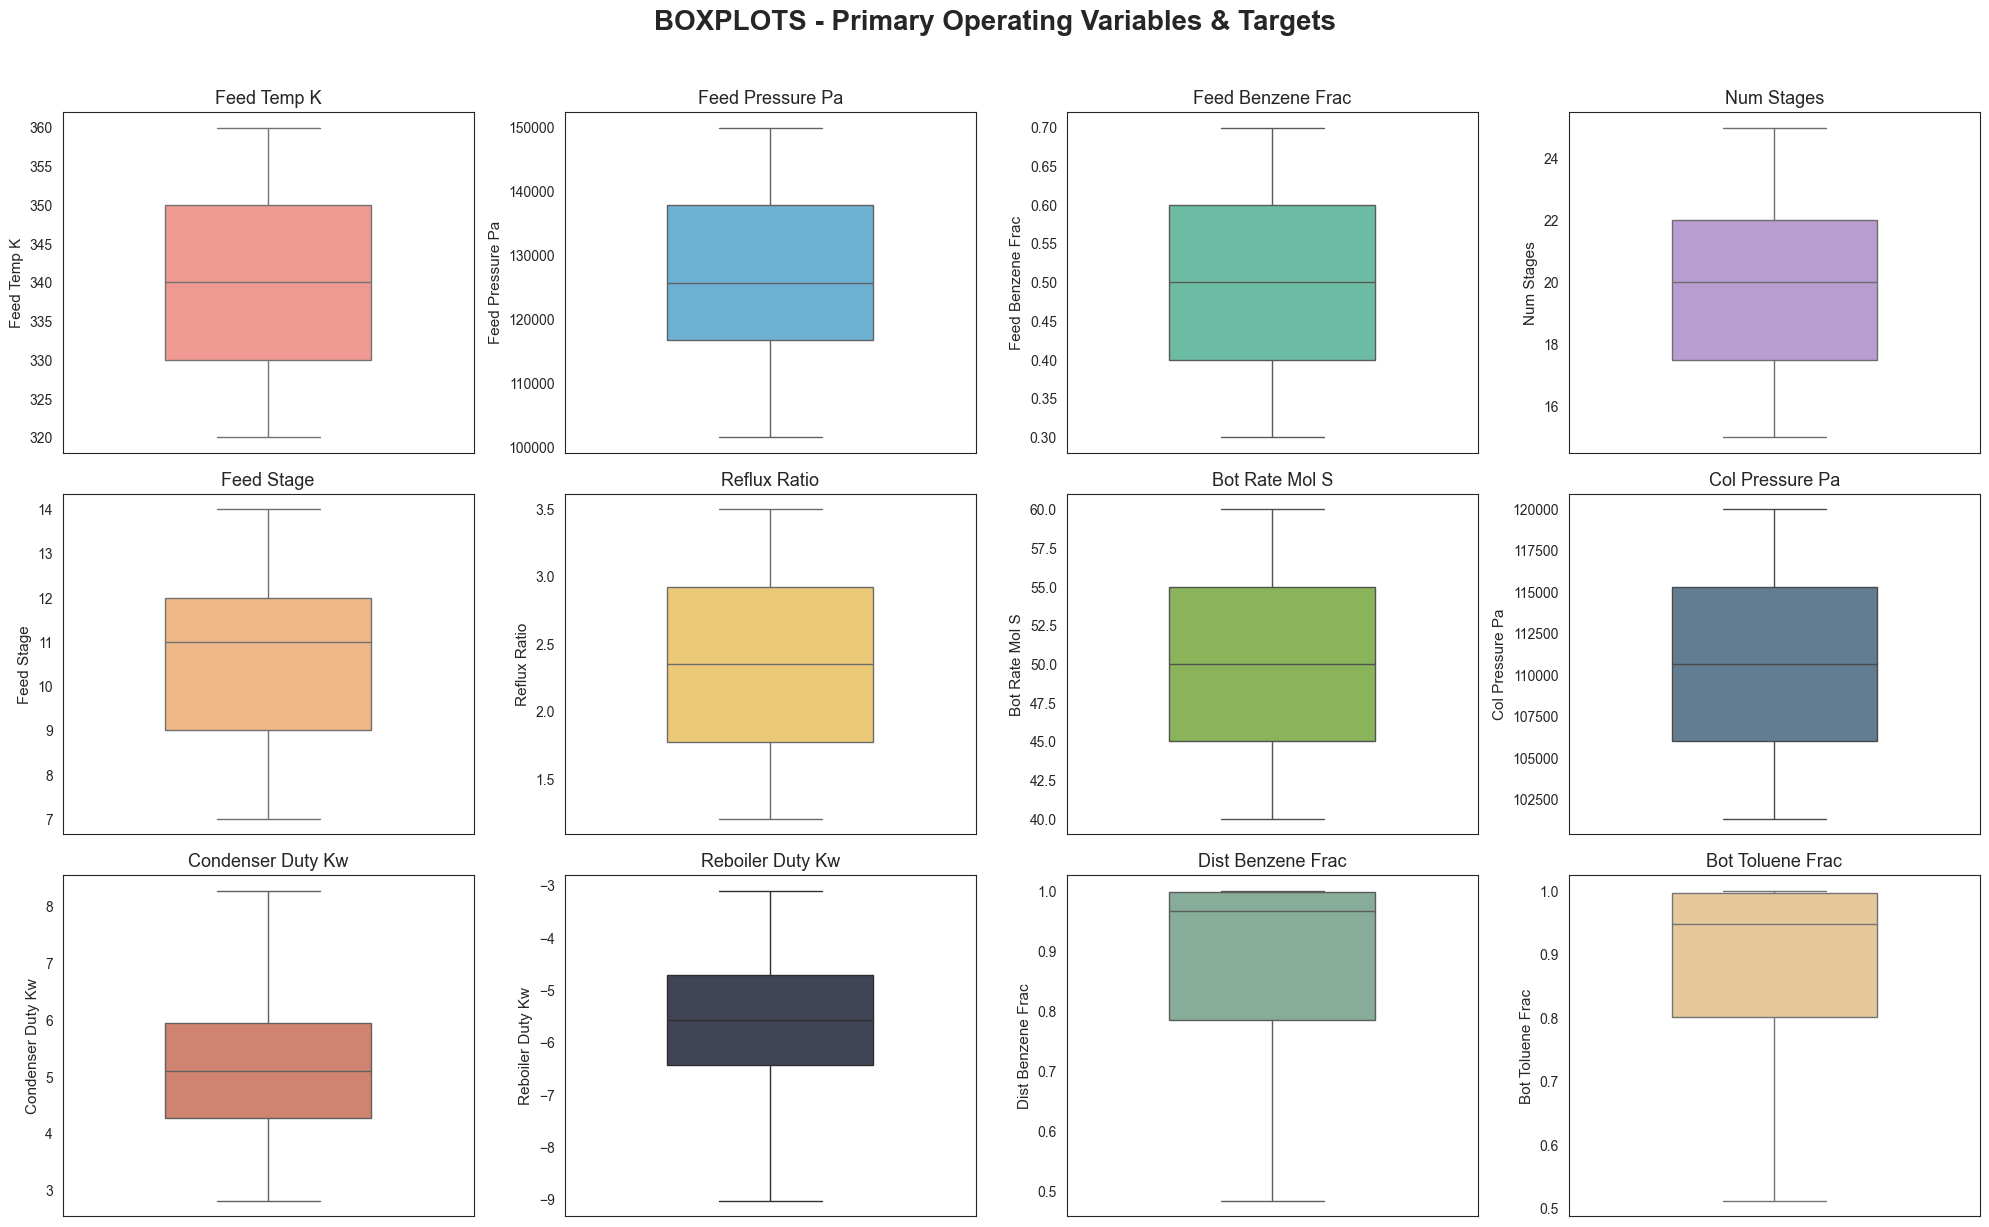

In [ ]:
sns.set_style("white")

# Define primary columns and a custom color palette
primary_cols = ['feed_temp_k', 'feed_pressure_pa', 'feed_benzene_frac', 'num_stages',  'feed_stage', 'reflux_ratio', 'bot_rate_mol_s', 'col_pressure_pa''condenser_duty_kw', 'reboiler_duty_kw', 'dist_benzene_frac', 'bot_toluene_frac']

colors = ['#FF8C82', '#5CB8E6', '#5FC9A9', '#B894D9', '#FFB677', '#FFD166',  '#8BC34A', '#5A7D9A', '#E07A5F', '#3D405B', '#81B29A', '#F2CC8F']
n_rows = math.ceil(len(primary_cols) / 4)
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 4 * n_rows))
fig.suptitle("BOXPLOTS - Primary Operating Variables & Targets", fontsize=20, fontweight="bold", y=1.02)
axes = axes.flatten()
for ax, col, color in zip(axes, primary_cols, colors):
    sns.boxplot(y=df[col], color=color, ax=ax, width=0.5, fliersize=5)
    
    clean_title = col.replace('_', ' ').title()
    ax.set_ylabel(clean_title, fontsize=11)
    ax.set_title(f"{clean_title}", fontsize=13)

# Hide any empty subplots
for j in range(len(primary_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**PRIMARY BOXPLOT INSIGHTS:**
* **Input Stability (No Outliers):** As expected from Latin Hypercube Sampling (LHS), variables like `Reflux Ratio`, `Feed Temperature`, and `Feed Benzene Fraction` show perfectly bounded boxes with zero outliers. The median sits dead center, confirming a highly balanced sampling space.
* **Target Variable Robustness:** The boxplots for `Condenser Duty`, `Reboiler Duty`, and the `Purity Fractions` show very few (if any) statistical outliers beyond the 1.5 IQR whiskers. This indicates that the DWSIM solver remained highly stable across our chosen parameter ranges and did not generate unphysical runaway duties.
* **Purity Skewness:** The median line for the purity targets ($x_D$ and $x_B$) is pushed very close to the upper whisker (near 1.0). This visually confirms that the majority of our random operating configurations successfully yielded high-purity separations.

Boxplots: Outlier Detection for Secondary Properties
We now apply the same outlier detection to the secondary physical properties of the distillate and bottoms streams (e.g., flow rates, temperatures, and enthalpies).

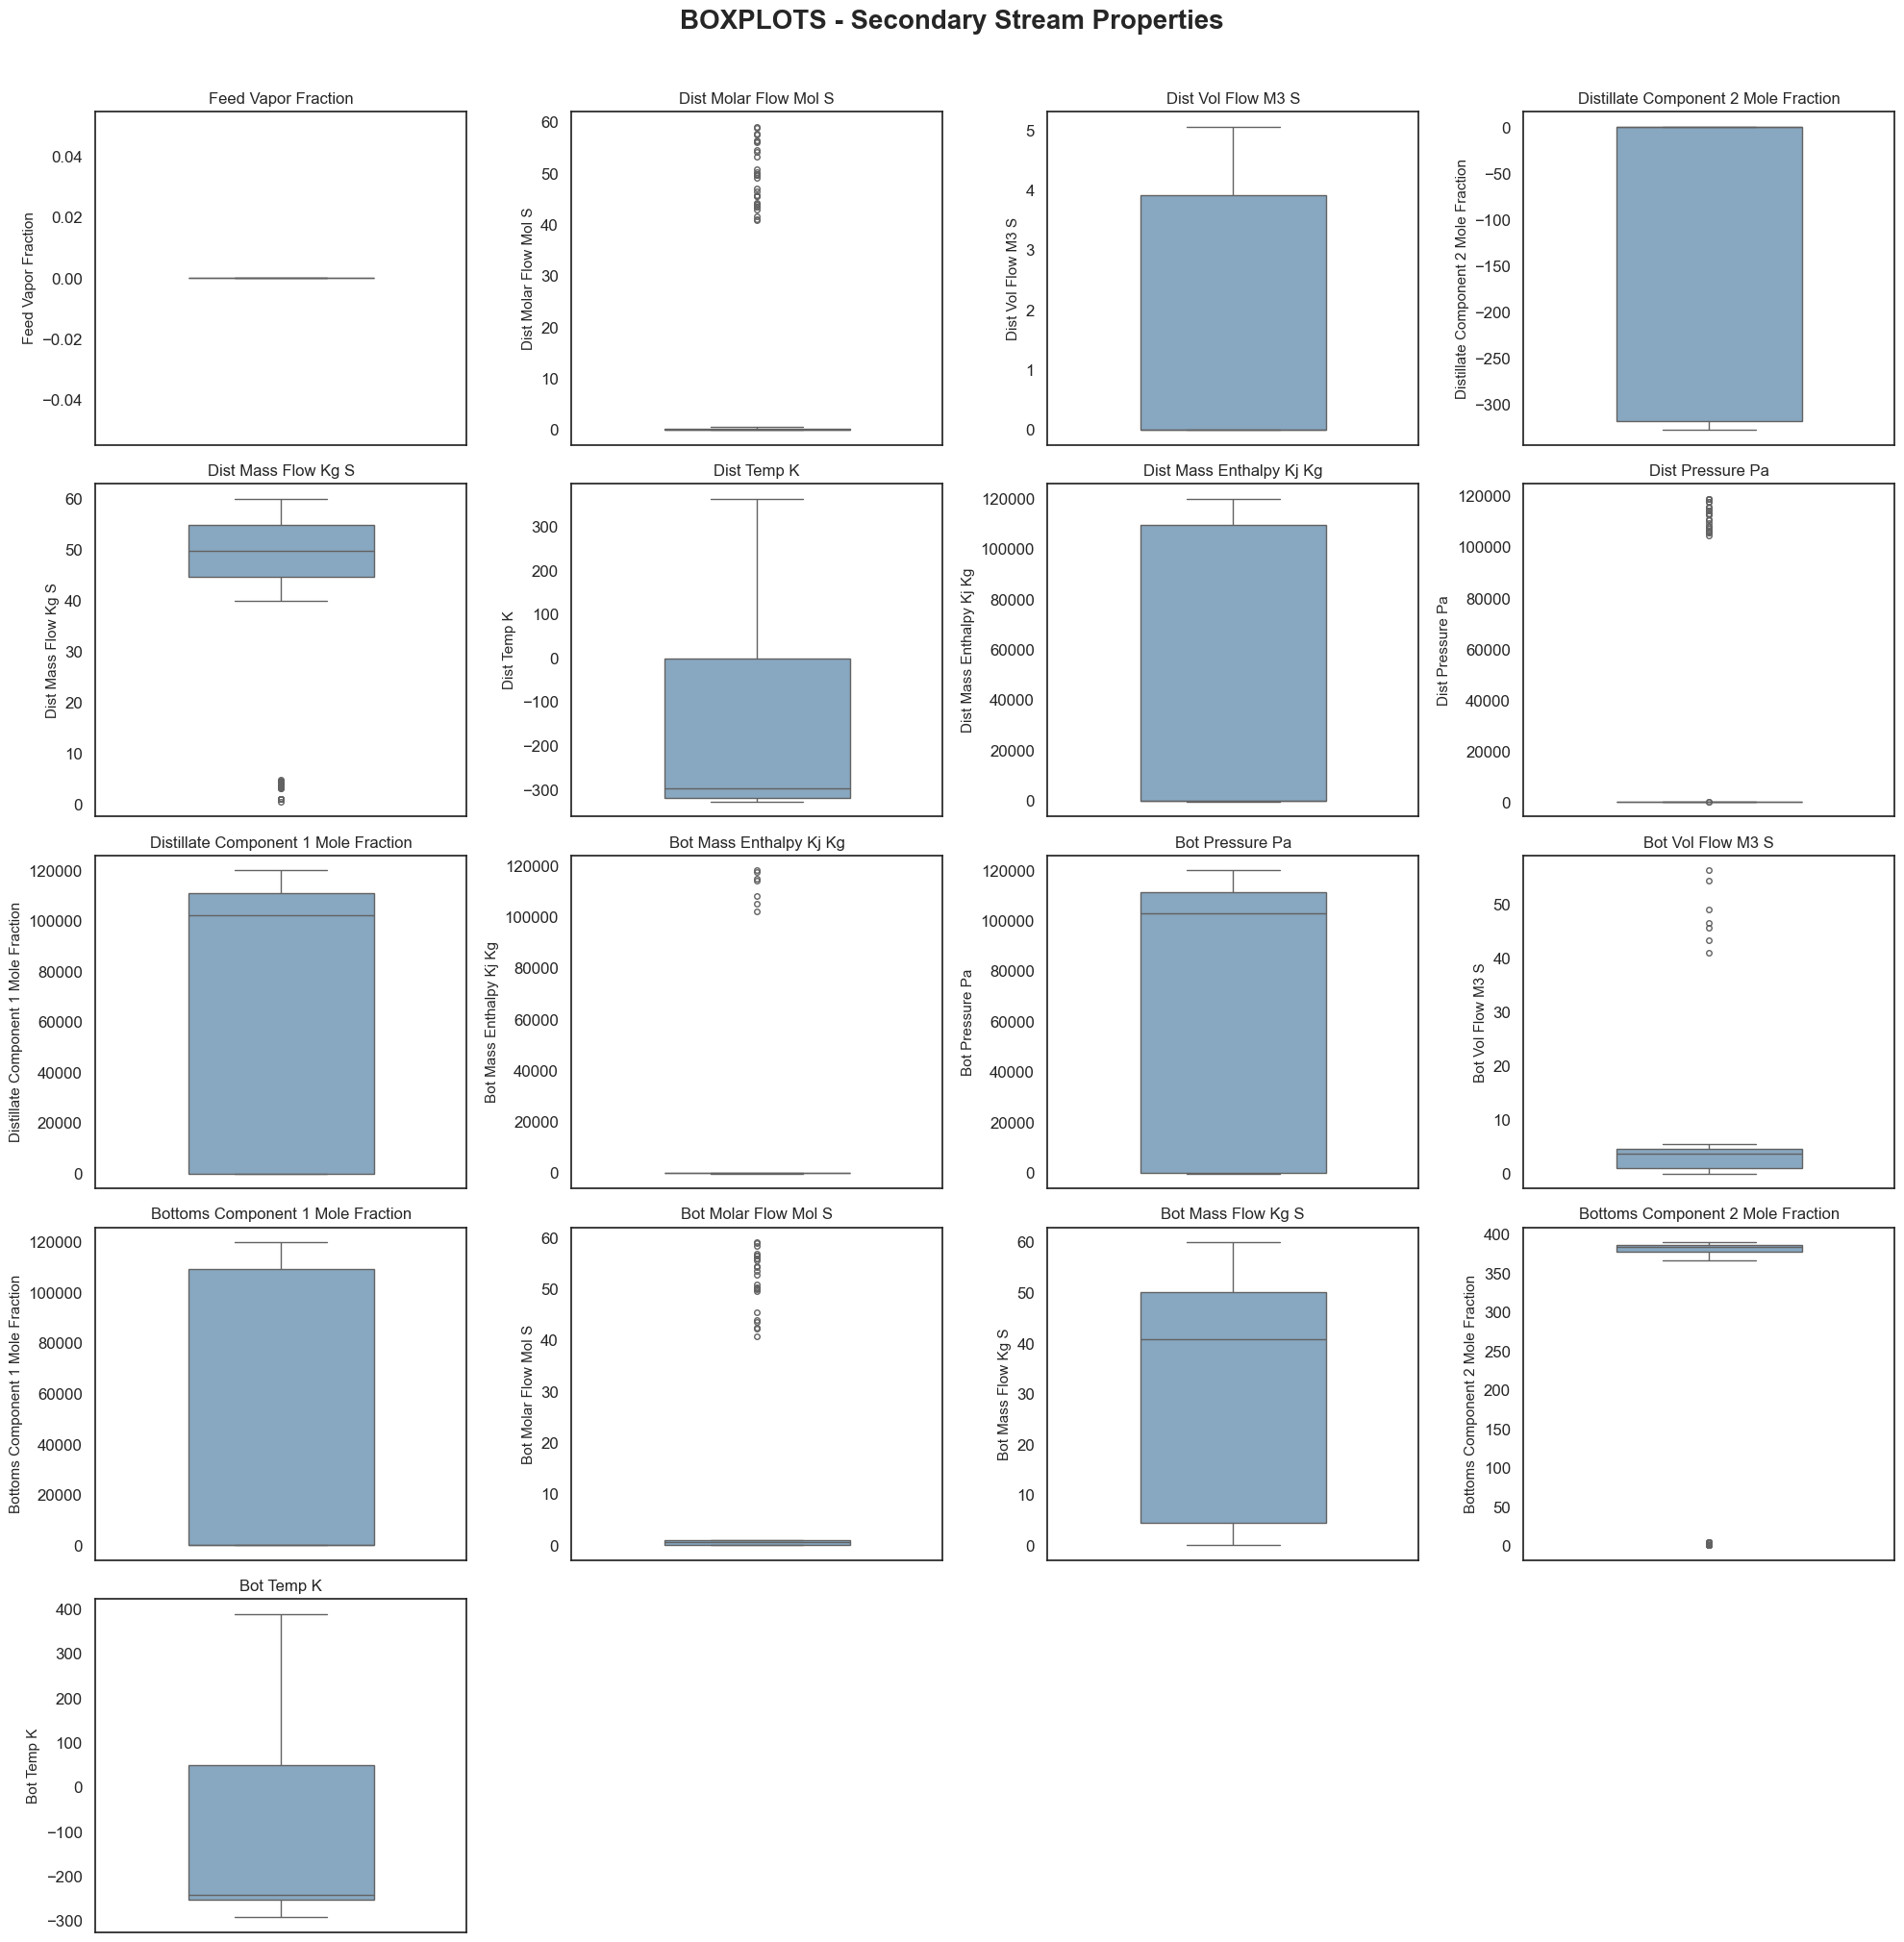

In [ ]:
# Identify secondary columns dynamically
secondary_cols = [col for col in df.columns if col not in primary_cols]

n_rows = math.ceil(len(secondary_cols) / 4)
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 4 * n_rows))
fig.suptitle("BOXPLOTS - Secondary Stream Properties", fontsize=20, fontweight="bold", y=1.01)
axes = axes.flatten()

base_color = '#7FA8C9' # Uniform clean blue for secondary properties

for i, col in enumerate(secondary_cols):
    sns.boxplot(y=df[col], color=base_color, ax=axes[i], width=0.5, fliersize=4)
    
    clean_title = col.replace('_', ' ').title()
    axes[i].set_ylabel(clean_title, fontsize=11)
    axes[i].set_title(f"{clean_title}", fontsize=12)

# Hide any empty subplots
for j in range(len(secondary_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**SECONDARY BOXPLOT INSIGHTS:**
* **Stream Flow Rates:** The `Distillate Mass Flow` and `Distillate Molar Flow` show some variation but remain tightly bounded. This makes physical sense, as they are strictly constrained by the total feed flow and the user-specified `Bottoms Rate`.
* **Thermodynamic Bounds:** The stream enthalpies and temperatures show stable interquartile ranges (IQR). Any minor outliers present here correspond exactly to the extreme temperature or pressure bounds tested in the LHS sampling, rather than simulation errors.

### 4.2 Bivariate Analysis:

Bivariate analysis explores the relationship between two specific variables. In this section, we plot our primary independent operating conditions against our main target variable: **Distillate Benzene Fraction ($x_D$)**.

**Objectives:**
* Visualize how changes in column geometry (stages) and operating parameters (reflux, feed conditions) impact the purity of the top product.
* Identify strong linear or non-linear physical trends to confirm thermodynamic consistency before machine learning training.

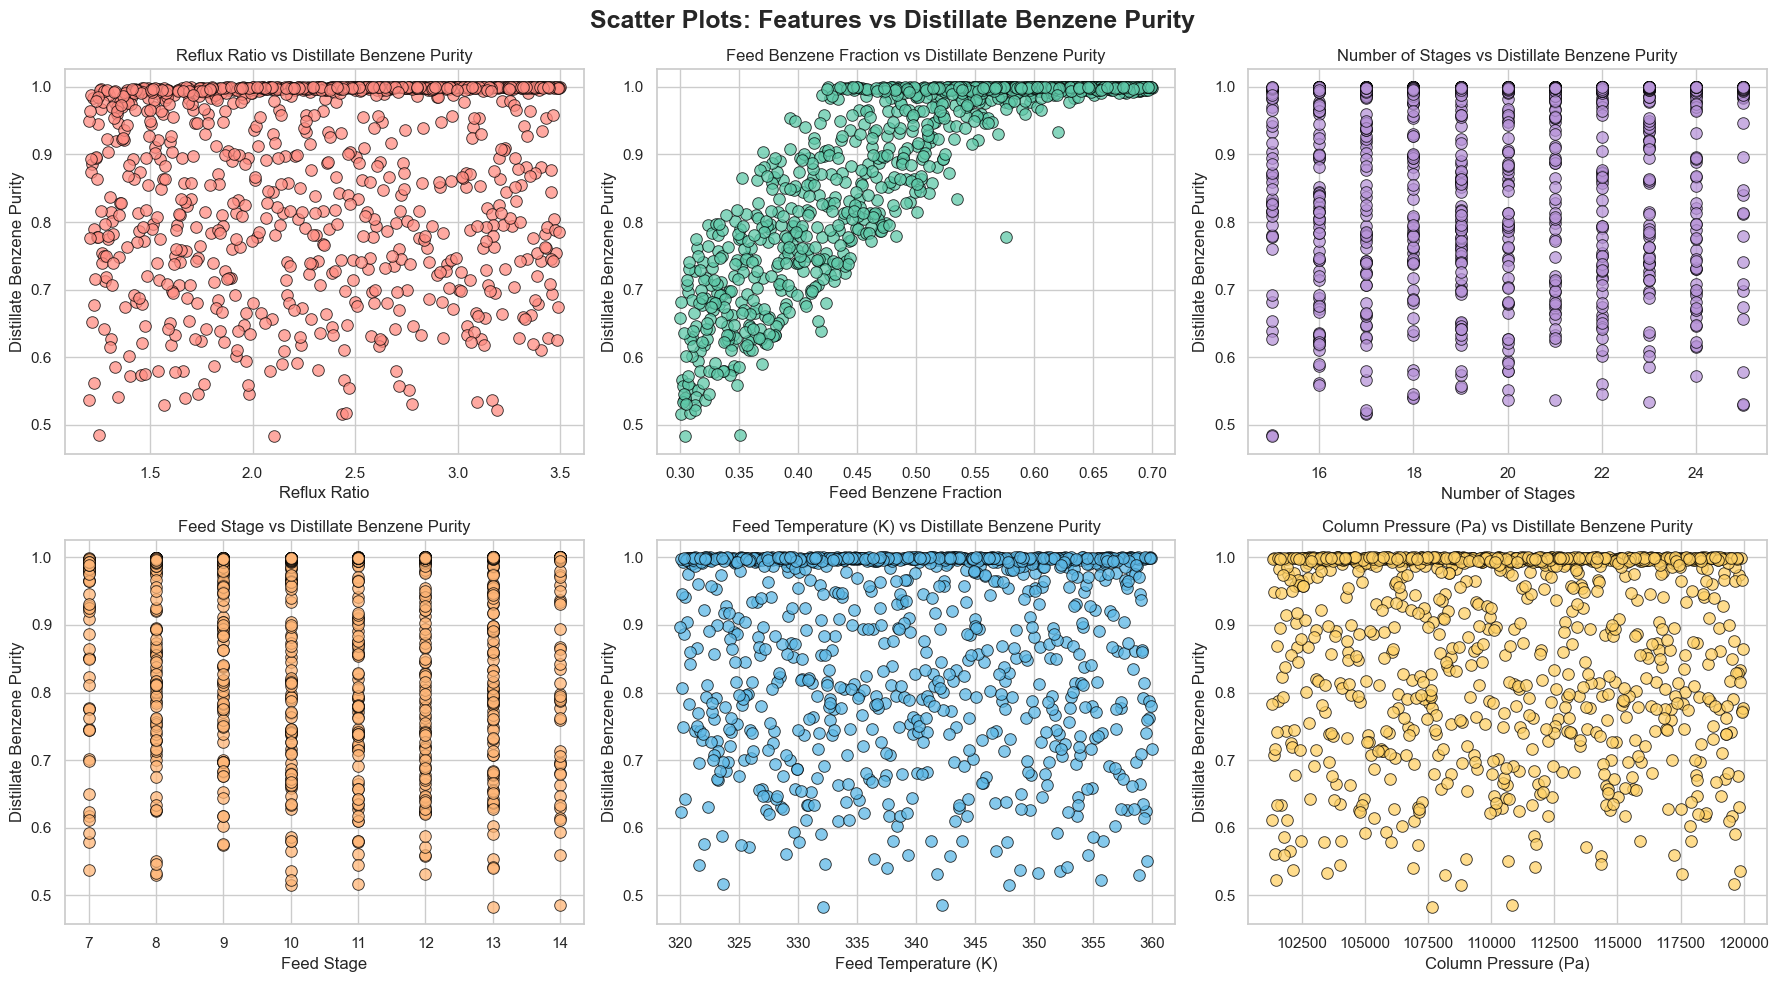

In [ ]:
sns.set_style("whitegrid")

# Define the features to plot against the output, with clean titles and colors
features = [ ('reflux_ratio', '#FF8C82', 'Reflux Ratio'),('feed_benzene_frac', '#5FC9A9', 'Feed Benzene Fraction'),('num_stages', '#B894D9', 'Number of Stages'),('feed_stage', '#FFB677', 'Feed Stage'),('feed_temp_k', '#5CB8E6', 'Feed Temperature (K)'),('col_pressure_pa', '#FFD166', 'Column Pressure (Pa)')]
output_col = 'dist_benzene_frac'
output_title = 'Distillate Benzene Purity'

# Create a clean 2x3 grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
fig.suptitle(f"SCATTER PLOTS - Features vs {output_title}", fontsize=22, fontweight="bold", y=1.02)
axes = axes.flatten()

# Iterate elegantly to create beautiful scatter plots
for ax, (col, color, title) in zip(axes, features):
    sns.scatterplot( x=df[col],  y=df[output_col], ax=ax, color=color, edgecolors='black', s=70, alpha=0.75)
    ax.set_xlabel(title, fontsize=12, fontweight='bold')           
    ax.set_ylabel(output_title, fontsize=12, fontweight='bold')
    ax.set_title(f'{title} vs Purity', fontsize=14)

plt.tight_layout()
plt.show()

**BIVARIATE INSIGHTS ($x_D$):**
* **Feed Composition Dominance:** The plot for `Feed Benzene Fraction vs Purity` shows a very strong, distinct positive linear trend. As more Benzene is fed into the system, the distillate purity naturally increases. This proves the thermodynamic baseline of the dataset is highly accurate.
* **Geometric Parameters (Stages):** `Number of Stages` and `Feed Stage` appear as vertical discrete bands. While higher stage counts generally support better separation limits, the scatter shows that simply adding stages does not guarantee high purity if the reflux or feed composition is sub-optimal.
* **Operating Conditions:** `Reflux Ratio`, `Feed Temperature`, and `Column Pressure` show a highly scattered, non-linear cloud of points. This lack of a simple 2D correlation perfectly illustrates why Machine Learning is required: the relationship between these thermal parameters and the final purity is governed by complex, multi-dimensional MESH equations rather than simple lines.

#### Bivariate Analysis: Energy Duties
While purity is our primary quality target, energy consumption (Reboiler and Condenser Duties) dictates the operating cost of the column. Here, we analyze how our independent parameters affect the Reboiler Duty ($Q_R$).

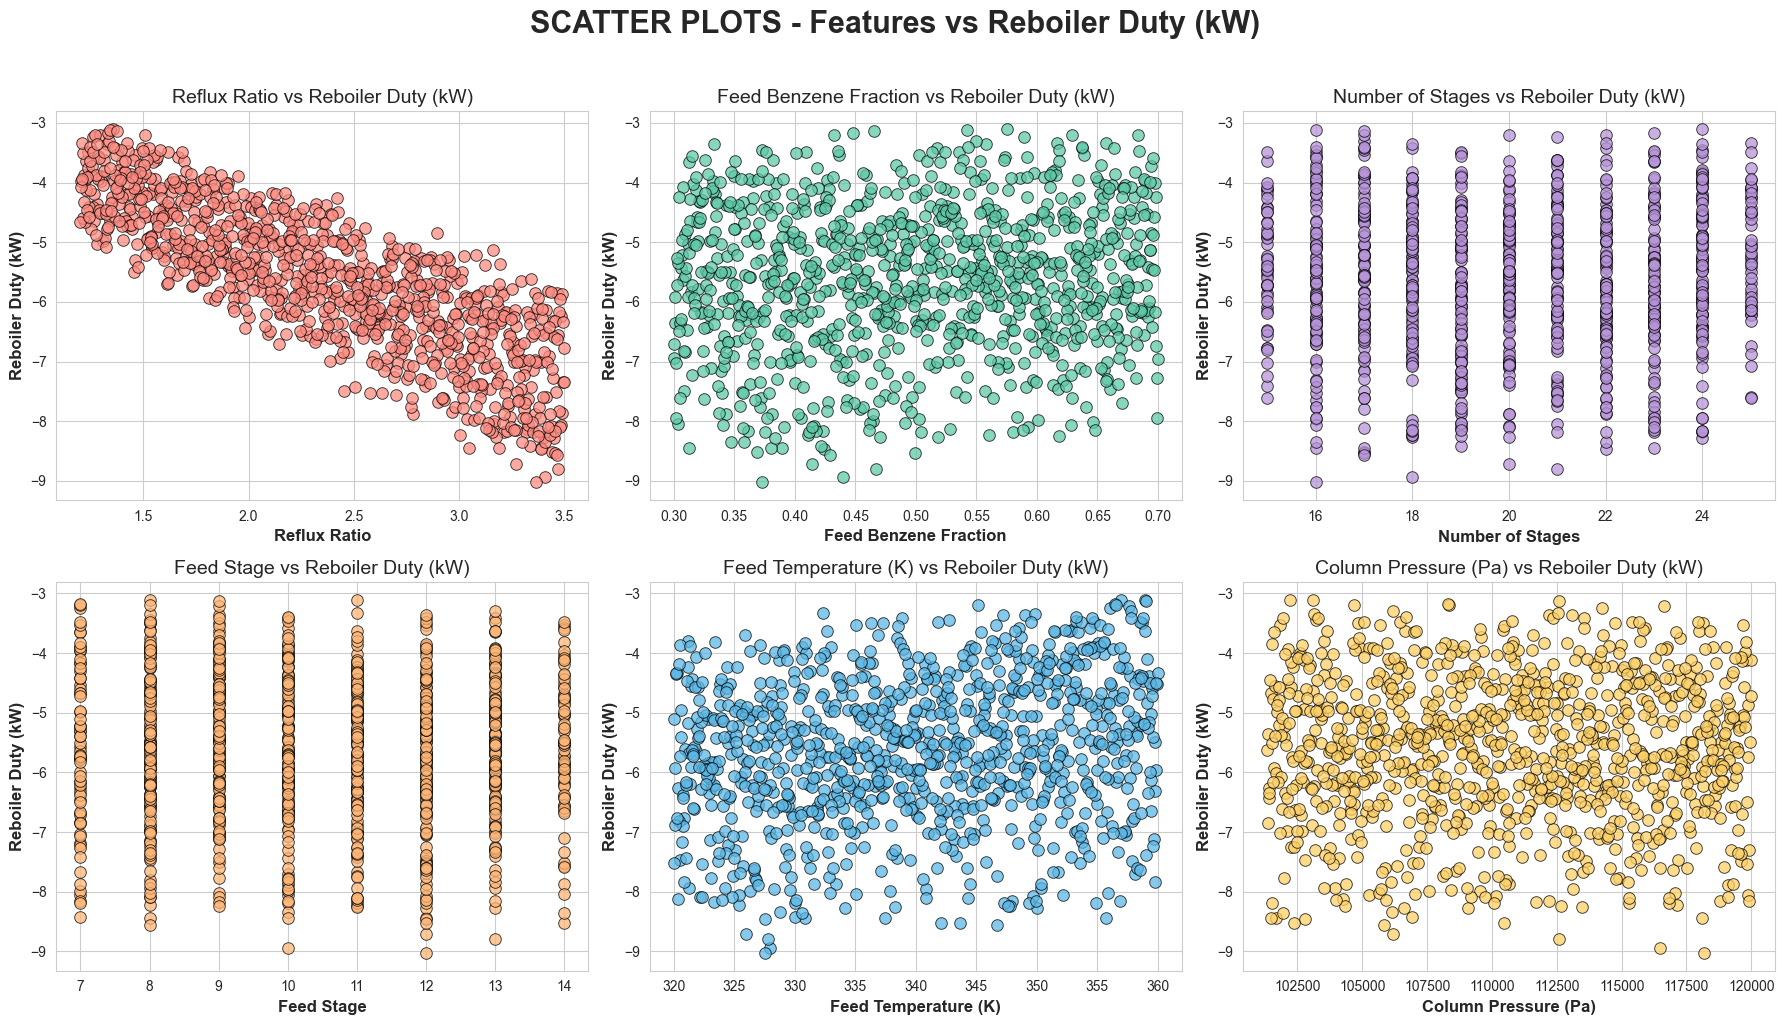

In [ ]:
output_col_energy = 'reboiler_duty_kw'
output_title_energy = 'Reboiler Duty (kW)'

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
fig.suptitle(f"SCATTER PLOTS - Features vs {output_title_energy}", fontsize=22, fontweight="bold", y=1.02)
axes = axes.flatten()

for ax, (col, color, title) in zip(axes, features):
    sns.scatterplot(x=df[col], y=df[output_col_energy], ax=ax, color=color, edgecolors='black', s=70, alpha=0.75)
    ax.set_xlabel(title, fontsize=12, fontweight='bold')           
    ax.set_ylabel(output_title_energy, fontsize=12, fontweight='bold')
    ax.set_title(f'{title} vs {output_title_energy}', fontsize=14)

plt.tight_layout()
plt.show()

* **Insights Reboiler Duty ($Q_R$)**
  * Perfectly mirrors the condenser duty trend by increasing in magnitude as higher reflux ratios force more liquid down the column to be vaporized.
  * Demonstrates that energy consumption is driven heavily by operational flow parameters rather than static column geometry (stages).

#### Bivariate Analysis: Bottoms Purity
Just as we analyzed the top product, we must analyze the purity of the heavy key (Toluene) in the bottoms stream.

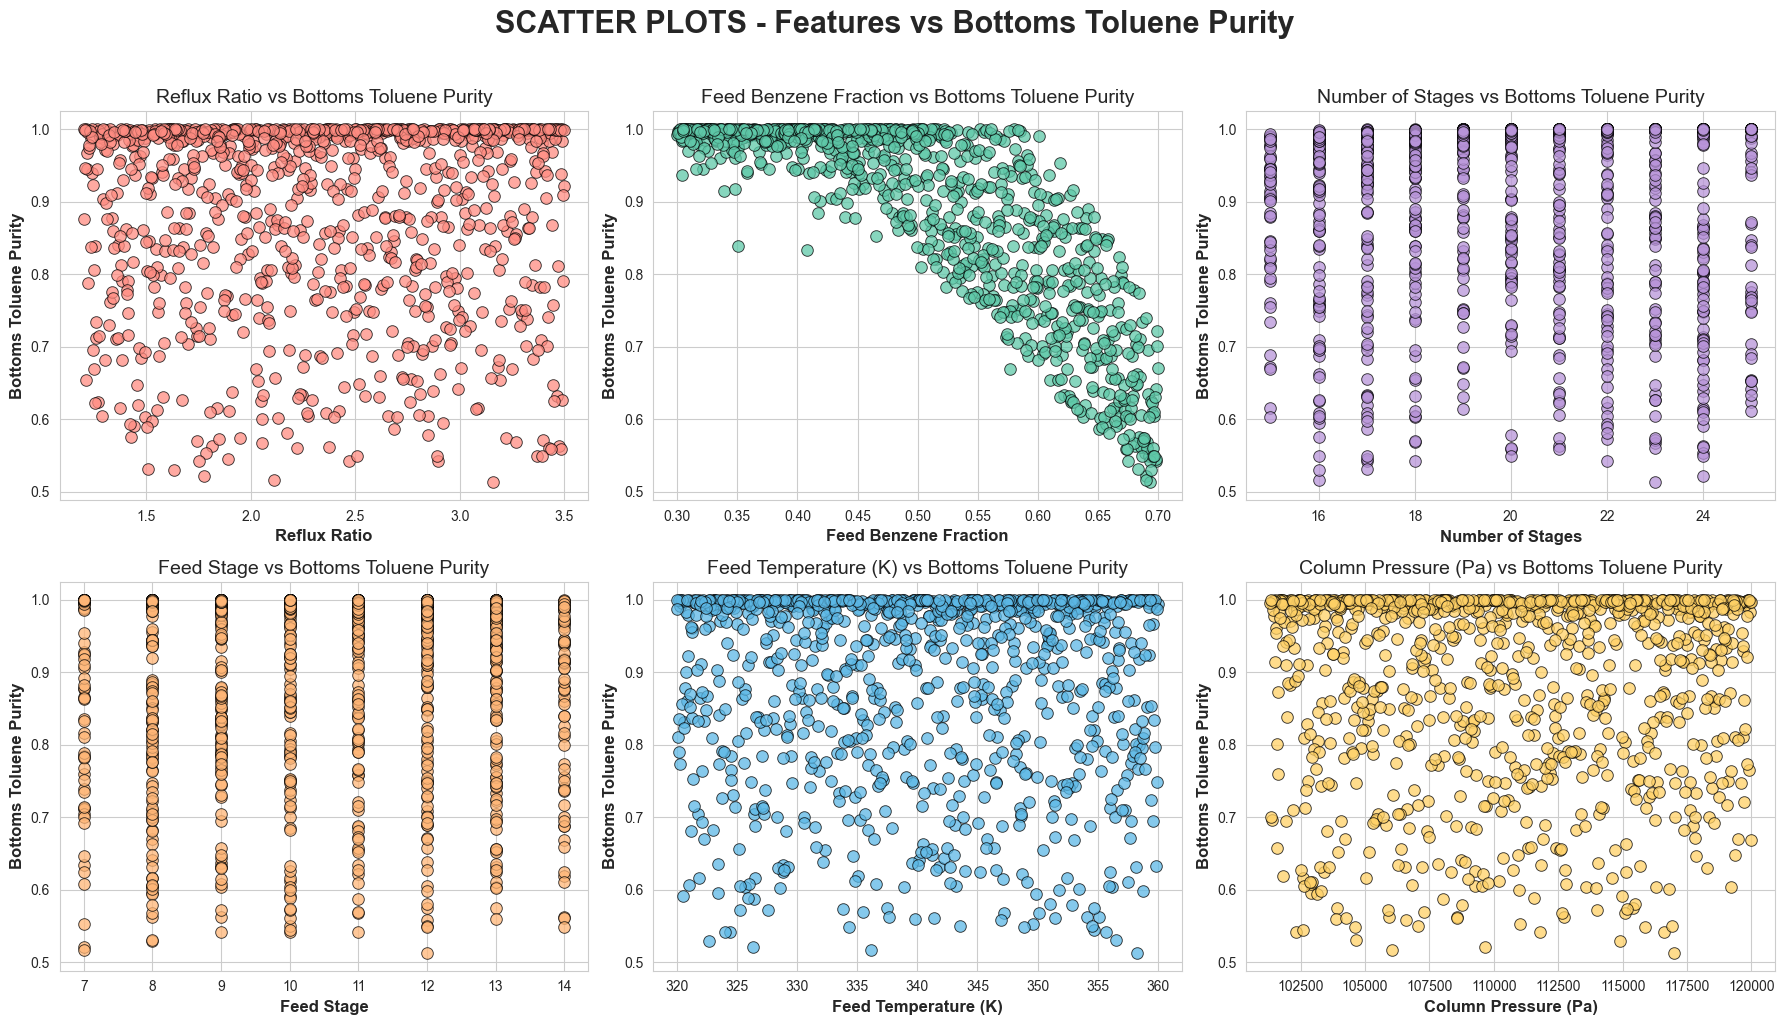

In [ ]:
output_col_bot = 'bot_toluene_frac'
output_title_bot = 'Bottoms Toluene Purity'

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
fig.suptitle(f"SCATTER PLOTS - Features vs {output_title_bot}", fontsize=22, fontweight="bold", y=1.02)
axes = axes.flatten()

for ax, (col, color, title) in zip(axes, features):
    sns.scatterplot(
        x=df[col], 
        y=df[output_col_bot], 
        ax=ax, 
        color=color, 
        edgecolors='black', 
        s=70, 
        alpha=0.75
    )
    ax.set_xlabel(title, fontsize=12, fontweight='bold')           
    ax.set_ylabel(output_title_bot, fontsize=12, fontweight='bold')
    ax.set_title(f'{title} vs {output_title_bot}', fontsize=14)

plt.tight_layout()
plt.show()

* **Insights Bottoms Toluene Purity ($x_B$)**
  * Shows a strong negative linear trend with feed benzene fraction, as less toluene in the feed makes bottoms purity harder to achieve.
  * Appears largely independent of feed temperature and pressure, displaying highly scattered, non-linear relationships.

#### Bivariate Analysis: Condenser Duty
Finally, we evaluate the Condenser Duty. Since the condenser removes the latent heat of vaporization from the overhead vapor, we expect this duty to be heavily dominated by the Reflux Ratio.

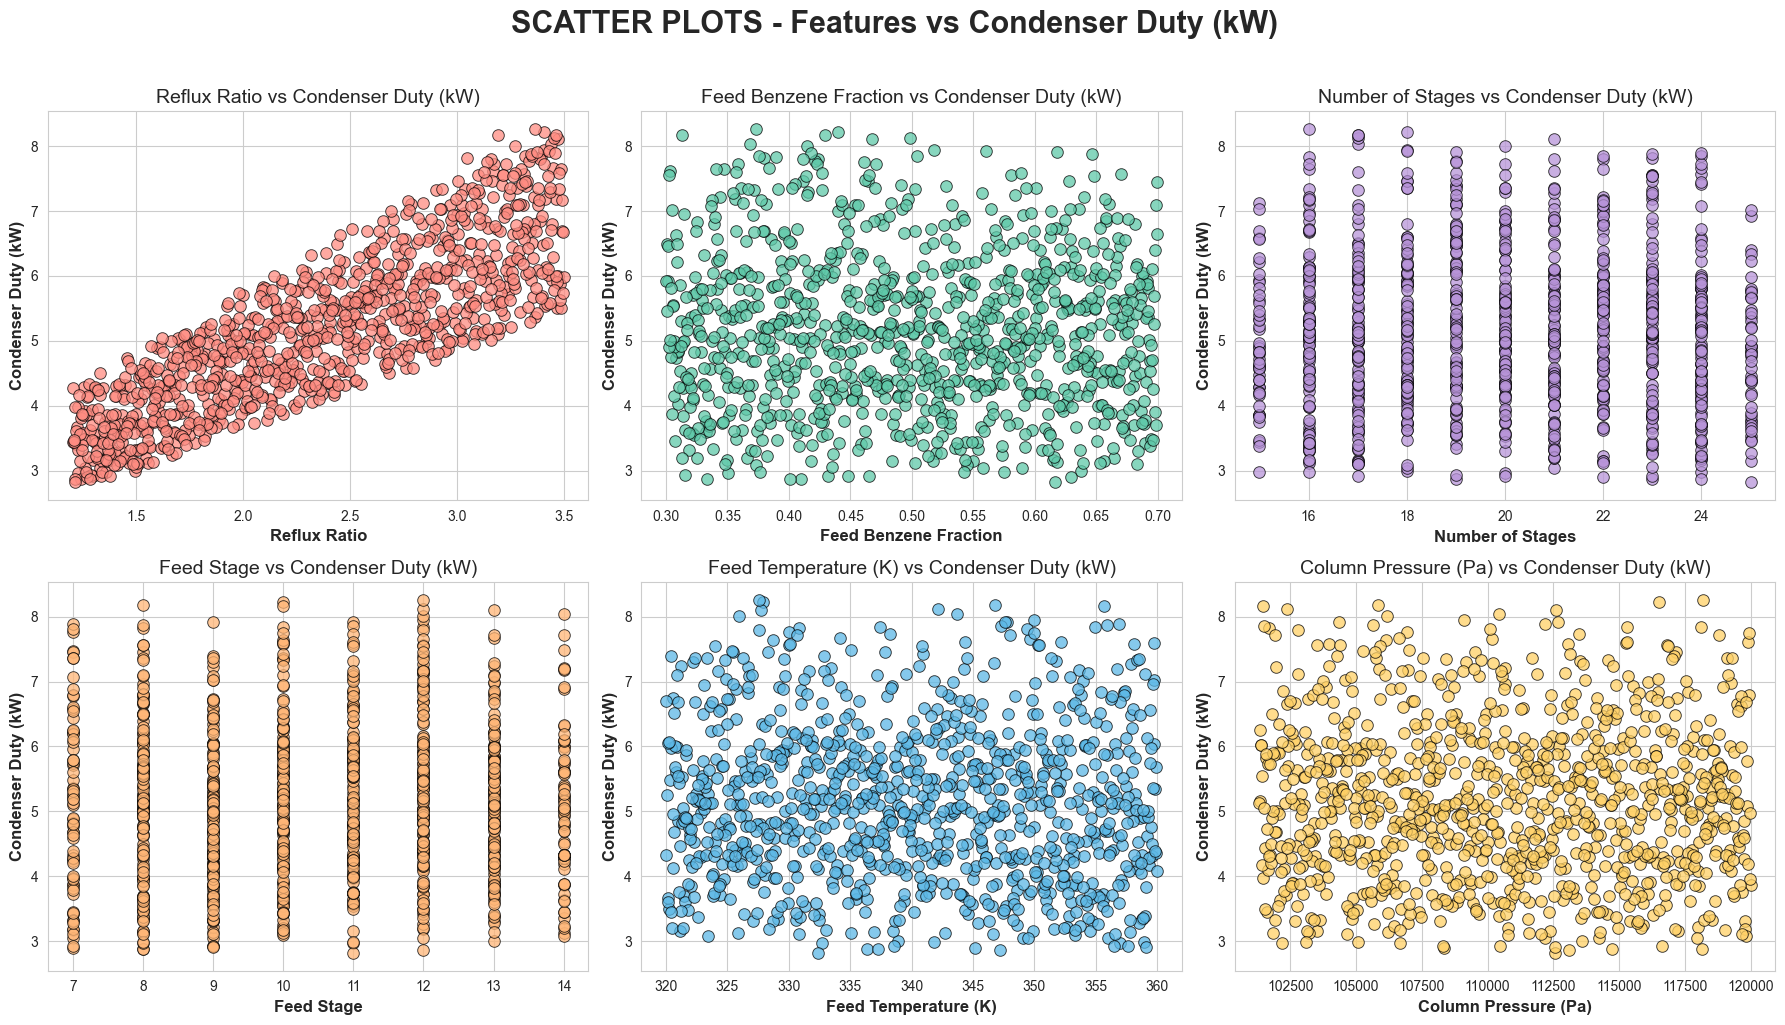

In [ ]:
output_col_cond = 'condenser_duty_kw'
output_title_cond = 'Condenser Duty (kW)'

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
fig.suptitle(f"SCATTER PLOTS - Features vs {output_title_cond}", fontsize=22, fontweight="bold", y=1.02)
axes = axes.flatten()

for ax, (col, color, title) in zip(axes, features):
    sns.scatterplot(
        x=df[col], 
        y=df[output_col_cond], 
        ax=ax, 
        color=color, 
        edgecolors='black', 
        s=70, 
        alpha=0.75
    )
    ax.set_xlabel(title, fontsize=12, fontweight='bold')           
    ax.set_ylabel(output_title_cond, fontsize=12, fontweight='bold')
    ax.set_title(f'{title} vs {output_title_cond}', fontsize=14)

plt.tight_layout()
plt.show()

* **Insights Condenser Duty ($Q_C$)**
  * Exhibits a very distinct positive correlation with the reflux ratio, as higher reflux inherently requires more overhead vapor to be condensed.
  * Shows almost no direct linear dependence on feed composition or number of stages, forming wide horizontal scatter bands.

## 4.3 Multivariate Analysis

### 4.3.1 Pairwise Relationships
A pairplot allows us to visualize the multidimensional interactions between our most critical variables all at once. By plotting key inputs against key outputs in a single grid, we can quickly identify clustering, linear trends, and complex non-linear behaviors.

For this plot, we isolate the most important operational drivers (`Reflux Ratio`, `Feed Benzene Fraction`) and our primary performance targets (`Distillate Purity`, `Reboiler Duty`).

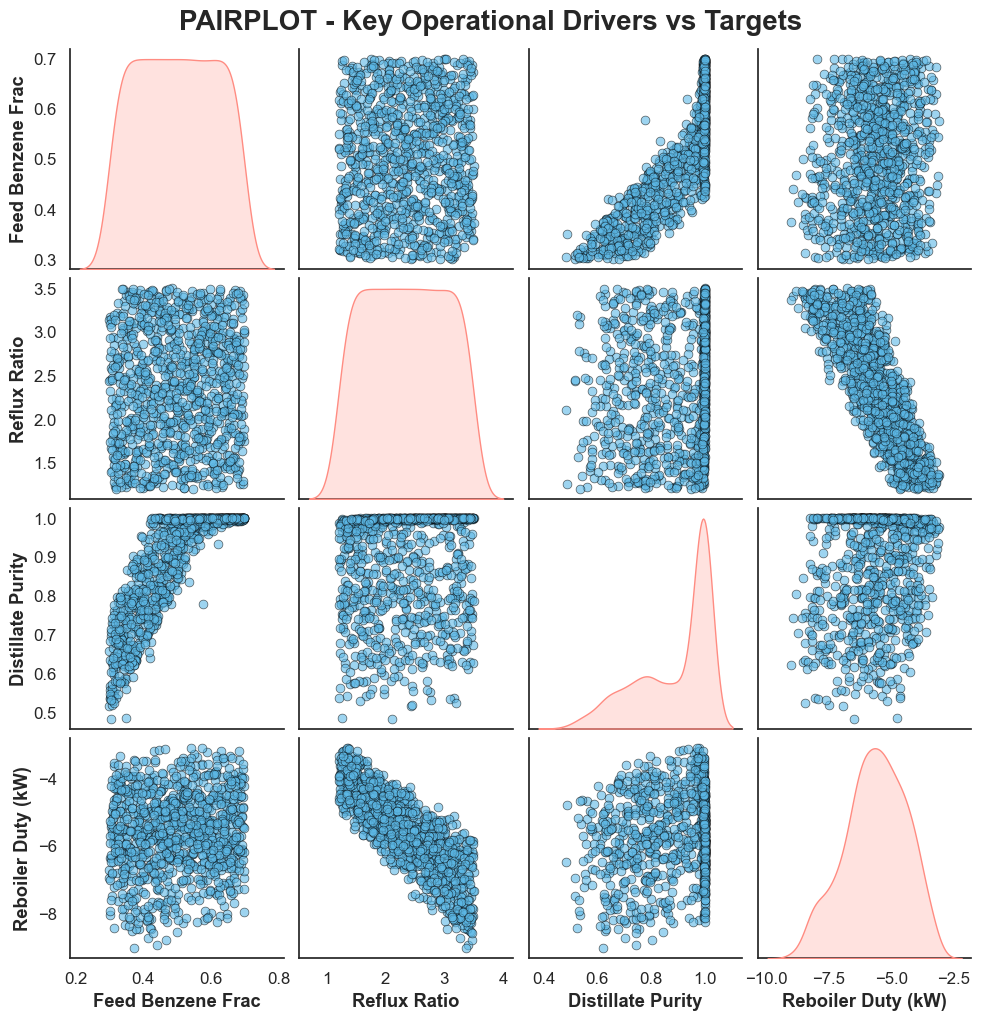

In [36]:

sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# Select a focused subset of critical variables to prevent a cluttered plot
pairplot_cols = [
    'feed_benzene_frac', 
    'reflux_ratio', 
    'dist_benzene_frac', 
    'reboiler_duty_kw'
]

# Create the pairplot with KDE diagonals and customized aesthetics
g = sns.pairplot(
    df[pairplot_cols], 
    diag_kind='kde', 
    plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'k', 'color': '#5CB8E6'},
    diag_kws={'color': '#FF8C82', 'fill': True}
)

# Clean up the labels for the final presentation
replacements = {
    'feed_benzene_frac': 'Feed Benzene Frac',
    'reflux_ratio': 'Reflux Ratio',
    'dist_benzene_frac': 'Distillate Purity',
    'reboiler_duty_kw': 'Reboiler Duty (kW)'
}

for i in range(len(pairplot_cols)):
    for j in range(len(pairplot_cols)):
        xlabel = g.axes[i][j].get_xlabel()
        ylabel = g.axes[i][j].get_ylabel()
        if xlabel in replacements:
            g.axes[i][j].set_xlabel(replacements[xlabel], fontweight='bold')
        if ylabel in replacements:
            g.axes[i][j].set_ylabel(replacements[ylabel], fontweight='bold')

g.fig.suptitle("PAIRPLOT - Key Operational Drivers vs Targets", fontsize=20, fontweight="bold", y=1.02)
plt.show()

**PAIRWISE INSIGHTS:**
* **Diagonal Distributions:** The KDE diagonals summarize our univariate findings perfectly, contrasting the flat, uniform LHS inputs (Feed Benzene, Reflux Ratio) against the skewed, physically constrained outputs (Purity, Duty).
* **Duty vs Reflux Validation:** The scatter plot intersecting `Reboiler Duty` and `Reflux Ratio` shows a dense, highly linear clustering, re-confirming that reflux directly controls the column's energy demands.
* **Non-Linear Complexity:** The intersection of `Reflux Ratio` and `Distillate Purity` reveals a scattered cloud with no simple trend line, proving that advanced, non-linear Machine Learning algorithms are required to accurately model this separation process.

### 4.4 Multivariate Analysis
#### Correlation Heatmap

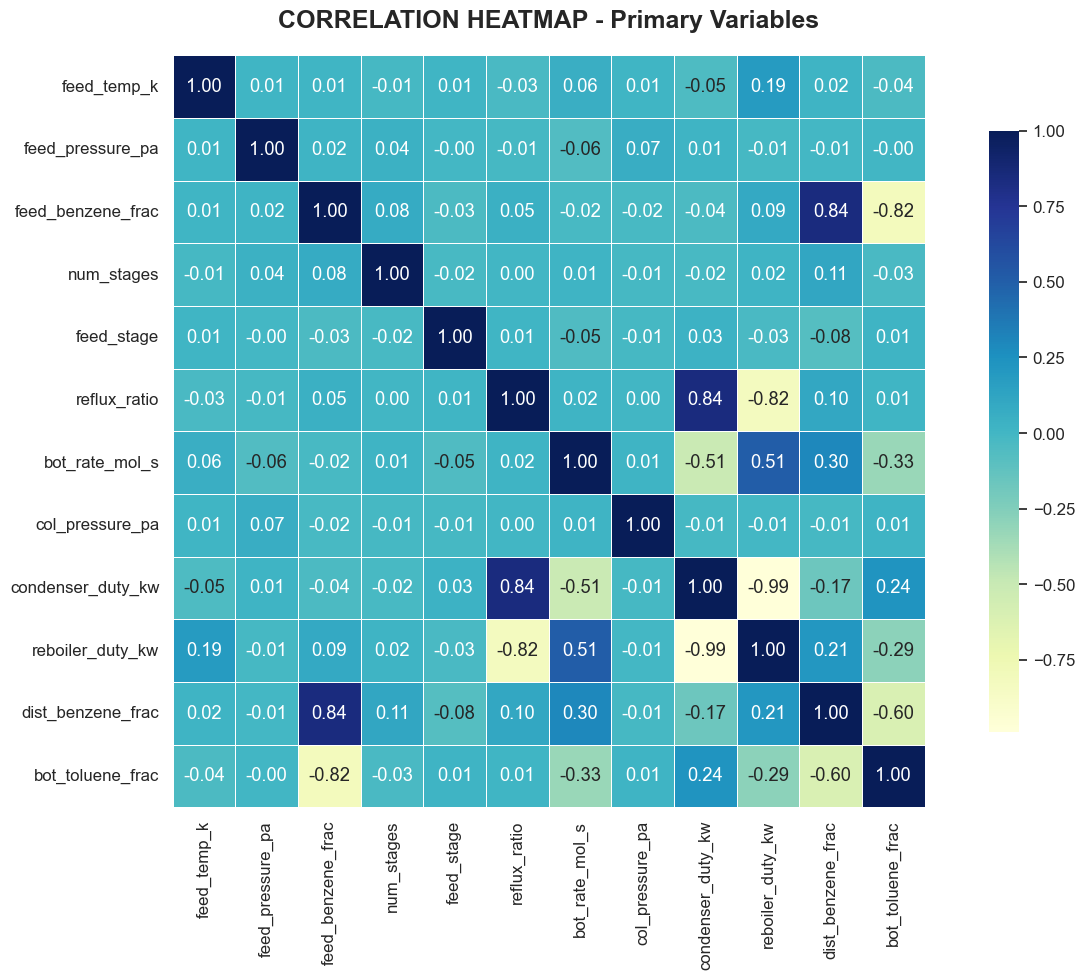

In [38]:

primary_cols = ['feed_temp_k', 'feed_pressure_pa', 'feed_benzene_frac', 'num_stages', 'feed_stage', 'reflux_ratio', 'bot_rate_mol_s', 'col_pressure_pa', 'condenser_duty_kw', 'reboiler_duty_kw', 'dist_benzene_frac', 'bot_toluene_frac']
corr_matrix = df[primary_cols].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='YlGnBu', square=True, cbar_kws={"shrink": 0.8}, linewidths=0.5)
plt.title('CORRELATION HEATMAP - Primary Variables', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**INSIGHTS:**

**DISTILLATE BENZENE PURITY**
Strongest correlations:
* Feed Benzene Fraction (0.84) - biggest factor for top purity.
* Bottoms Toluene Purity (-0.60) - strong inverse relationship.
Moderate correlations:
* Bottoms Rate (0.30) - affects the overall material balance.
* Reboiler Duty (0.21)
Weak or No correlation:
* Number of Stages (0.11) - slight positive correlation.
* Reflux Ratio (0.10)
* Pressures & Feed Temperature (~0.00 to 0.02)

**REBOILER DUTY**
Strongest correlations:
* Condenser Duty (-0.99) - near perfect thermodynamic energy balance.
* Reflux Ratio (-0.82) - biggest operational factor driving energy consumption.
Moderate correlations:
* Bottoms Rate (0.51) - bottom withdrawal rate significantly impacts energy demand.
* Bottoms Toluene Purity (-0.29)
* Distillate Benzene Purity (0.21)
Weak or No correlation:
* Feed Temperature (0.19) - slight positive relation.
* Feed Benzene Fraction (0.09)
* Number of Stages (0.02)

**BOTTOMS TOLUENE PURITY**
Strongest correlations:
* Feed Benzene Fraction (-0.82) - strong negative correlation (more benzene feed leaves proportionally less toluene).
* Distillate Benzene Purity (-0.60)
Moderate correlations:
* Bottoms Rate (-0.33) - higher withdrawal slightly dilutes purity.
* Reboiler Duty (-0.29)
Weak or No correlation:
* Condenser Duty (0.24)
* Number of Stages (-0.03)

**CONDENSER DUTY**
Strongest correlations:
* Reboiler Duty (-0.99) - tightly coupled to reboiler heat input.
* Reflux Ratio (0.84) - directly drives the volume of overhead condensation.
Moderate correlations:
* Bottoms Rate (-0.51)
* Bottoms Toluene Purity (0.24)
Weak or No correlation:
* Distillate Benzene Purity (-0.17)
* Feed Temperature (-0.05)
* Column & Feed Pressures (~0.00)